# Validation 03 — Waveform + Spectrogram (Cell 7)
Verifies synchronized axes, log-floor, frequency limit, and colourbar.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  nperseg = 50 ms × fs  → nperseg=2400
  [PASS]  Spectrogram output is 2-D
  [PASS]  No -inf in log spectrogram  → 1e-12 floor works
  [PASS]  Frequency capped at ≤5000 Hz  → 5000 Hz
  [PASS]  Spectrogram covers full signal  → t_spec end=89.20s
  [PASS]  Time vectors same length


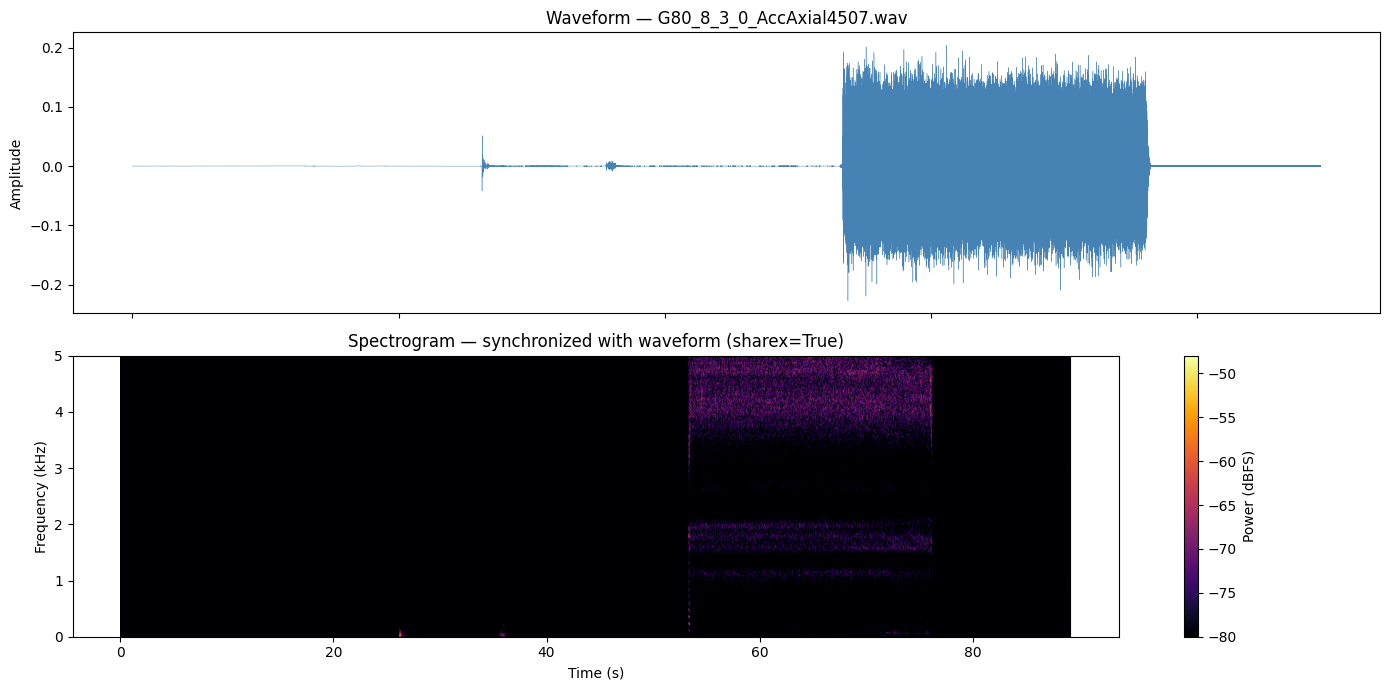

  [PASS]  sharex=True: axes share x-axis

  PASS: 7/7  |  FAIL: 0/7
  Score: 100%


In [3]:
if not EXAMPLE_WAV: raise SystemExit

fs,signal,duration = load_wav(EXAMPLE_WAV)
t = np.arange(len(signal))/fs

nperseg  = int(0.05*fs)
f_spec,t_spec,Sxx = sp_spectrogram(signal,fs=fs,nperseg=nperseg,noverlap=nperseg//2)
f_max_hz = min(fs/2, 5000)
f_mask   = f_spec<=f_max_hz
Sxx_db   = 10*np.log10(Sxx[f_mask]+1e-12)

check("nperseg = 50 ms × fs",          nperseg==int(0.05*fs),        f"nperseg={nperseg}")
check("Spectrogram output is 2-D",     Sxx.ndim==2)
check("No -inf in log spectrogram",    np.all(np.isfinite(Sxx_db)),  "1e-12 floor works")
check("Frequency capped at ≤5000 Hz",  f_spec[f_mask].max()<=5000,   f"{f_spec[f_mask].max():.0f} Hz")
check("Spectrogram covers full signal",abs(t_spec[-1]-duration)<0.5, f"t_spec end={t_spec[-1]:.2f}s")
check("Time vectors same length",      len(t)==len(signal))

fig,axes=plt.subplots(2,1,figsize=(14,7),sharex=True)
axes[0].plot(t,signal,lw=0.3,color='steelblue')
axes[0].set_ylabel('Amplitude'); axes[0].set_title(f'Waveform — {EXAMPLE_WAV.name}')
im=axes[1].pcolormesh(t_spec,f_spec[f_mask]/1000,Sxx_db,shading='gouraud',cmap='inferno',vmin=-80)
plt.colorbar(im,ax=axes[1],label='Power (dBFS)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Frequency (kHz)')
axes[1].set_title('Spectrogram — synchronized with waveform (sharex=True)')
plt.tight_layout(); plt.show(); plt.close('all')

check("sharex=True: axes share x-axis", axes[0].get_shared_x_axes().joined(axes[0],axes[1]))
summary()
